# 03 — Virtual screen of Enamine HLL for 5-HT2A activity

Apply the NB2 models to **Enamine's Hit Locator Library (HLL-460)**, a
pre-clustered diverse representation of Enamine's full 4.7M-compound in-stock
screening collection. ~460K compounds, drug-like, MedChem-filtered, free
download.

The pipeline is deliberately conservative: a high model score isn't enough.
A candidate must also pass

1. **Applicability domain**: by conformal prediction, $\alpha$ = 0.1
2. **Novelty** — not already in the training set by InChIKey
3. **no PAINS**

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem, Descriptors, Crippen, rdMolDescriptors, QED, Draw
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
RDLogger.DisableLog("rdApp.*")

USER_DIR = Path.cwd().resolve()
PROC = USER_DIR / "data" / "processed"
ENAMINE_FILE = USER_DIR / "data" / "Enamine" / "Enamine_Hit_Locator_Library_plated_460160cmpds_20260301.smiles"
RESULTS_DIR = PROC / "screen"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
N_BITS = 2048
RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

In [2]:
bundle = joblib.load(PROC / "models.joblib")
rf_model  = bundle["models"]["RF"]
xgb_model = bundle["models"]["XGB"]

DESCRIPTORS = {
    "MW":         Descriptors.MolWt,
    "LogP":       Crippen.MolLogP,
    "TPSA":       Descriptors.TPSA,
    "HBD":        rdMolDescriptors.CalcNumHBD,
    "HBA":        rdMolDescriptors.CalcNumHBA,
    "RotB":       rdMolDescriptors.CalcNumRotatableBonds,
    "NAromRings": rdMolDescriptors.CalcNumAromaticRings,
    "FracCSP3":   rdMolDescriptors.CalcFractionCSP3,
    "QED":        QED.qed,
    "HeavyAtoms": Descriptors.HeavyAtomCount,
    "NRings":     rdMolDescriptors.CalcNumRings,
    "FormalCharge": Chem.rdmolops.GetFormalCharge,
}
assert list(DESCRIPTORS) == bundle["descriptors"], "Descriptor list drifted from NB2"

_lfc       = rdMolStandardize.LargestFragmentChooser()
_uncharger = rdMolStandardize.Uncharger()

def standardize_and_featurize(smi):
    """Returns (smiles_std, inchikey, fp_array, desc_array) or None on failure."""
    if not isinstance(smi, str) or not smi:
        return None
    try:
        m = Chem.MolFromSmiles(smi)
        if m is None: return None
        m = rdMolStandardize.Cleanup(m)
        m = _lfc.choose(m)
        m = _uncharger.uncharge(m)
        smi_std = Chem.MolToSmiles(m)
        ik = Chem.MolToInchiKey(m)
        fp = AllChem.GetMorganFingerprintAsBitVect(m, 2, N_BITS)
        fp_arr = np.zeros((N_BITS,), dtype=np.uint8)
        DataStructs.ConvertToNumpyArray(fp, fp_arr)
        desc = np.array([fn(m) for fn in DESCRIPTORS.values()], dtype=np.float32)
        return smi_std, ik, fp_arr, desc
    except Exception:
        return None

In [ ]:
def iter_enamine(path, chunksize=20_000):
    return pd.read_csv(path, sep=r"\s+", engine="python", chunksize=chunksize,
                       usecols=[0, 1], names=["SMILES", "ID"], header=0,
                       on_bad_lines="skip")

peek = pd.read_csv(ENAMINE_FILE, sep=r"\s+", engine="python", nrows=3)
print("First rows of Enamine file:")
print(peek)

First rows of Enamine file:
                                                      SMILES      Catalog  \
0                        COC(=O)CNC(=O)COC1=CC=C2C=CC=CC2=C1    Z32888586   
1       CCOC(=O)CN1N=C(C)C=2C(=CC(=NC21)C=3C=CC=CC3)C(F)(F)F  Z2037166075   
2  CC1=CSC(=N1)NC(=O)C=2C=CC=C(C2)S(=O)(=O)N3C=4C=CC=CC4CC3C    Z30820341   

        ID       MW   MW.1  (desalted)  ClogP  logS    HBD  HBA  \
0  273.285  273.285  2.287      -3.838      1     3  64.63    6   
1  363.335  363.335  4.346      -4.652      0     3  57.01    6   
2  413.516  413.516  3.898      -5.611      1     4  79.37    3   

                                                     TPSA  RotBonds  \
0    https://real.enamine.net/public-enum-files/Z32888586       NaN   
1  https://real.enamine.net/public-enum-files/Z2037166075       NaN   
2    https://real.enamine.net/public-enum-files/Z30820341       NaN   

   AnalogsFromREAL  
0              NaN  
1              NaN  
2              NaN  


## Library prediction
 * Ensemble of random forrest and XGBoost from NB2 was used

In [4]:
chunk_records = []
for ci, chunk in enumerate(iter_enamine(ENAMINE_FILE)):
    feats = [standardize_and_featurize(s) for s in chunk["SMILES"]]
    keep  = [f is not None for f in feats]
    chunk = chunk.loc[keep].reset_index(drop=True)
    if chunk.empty: continue
    smi_std = [f[0] for f, k in zip(feats, keep) if k]
    ik      = [f[1] for f, k in zip(feats, keep) if k]
    fp_mat  = np.stack([f[2] for f, k in zip(feats, keep) if k])
    desc_mat = np.stack([f[3] for f, k in zip(feats, keep) if k])
    comb_mat = np.hstack([fp_mat, desc_mat]).astype(np.float32)

    rf_p  = rf_model.predict_proba(fp_mat)[:, 1]
    xgb_p = xgb_model.predict_proba(comb_mat)[:, 1]
    chunk = chunk.assign(smiles_std=smi_std, inchikey=ik,
                         rf_proba=rf_p, xgb_proba=xgb_p,
                         ensemble=(rf_p + xgb_p) / 2)
    chunk_records.append((chunk, fp_mat))
    print(f"  chunk {ci:3d}: {len(chunk):,} valid; "
          f"ensemble mean {chunk['ensemble'].mean():.3f}", end="\r")
print()

scored = pd.concat([r[0] for r in chunk_records], ignore_index=True)
scored_fps = np.vstack([r[1] for r in chunk_records])
print(f"\nScored {len(scored):,} valid compounds")
print(f"Predicted active (ensemble ≥ 0.5): {(scored['ensemble'] >= 0.5).sum():,} "
      f"({(scored['ensemble'] >= 0.5).mean():.1%})")

  chunk  23: 160 valid; ensemble mean 0.262257

Scored 460,160 valid compounds
Predicted active (ensemble ≥ 0.5): 27,974 (6.1%)


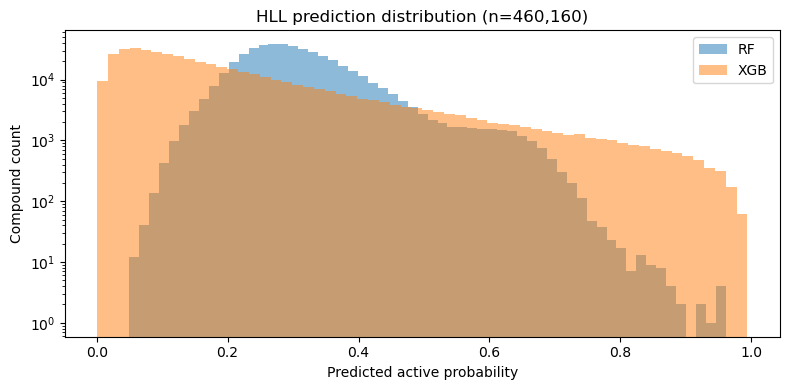

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(scored["rf_proba"],  bins=60, alpha=0.5, label="RF",  color="C0")
ax.hist(scored["xgb_proba"], bins=60, alpha=0.5, label="XGB", color="C1")
ax.set_xlabel("Predicted active probability")
ax.set_ylabel("Compound count")
ax.set_title(f"HLL prediction distribution (n={len(scored):,})")
ax.set_yscale("log")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "viz_screen_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
TOP_K = 2000
top = scored.nlargest(TOP_K, "ensemble").reset_index(drop=True)
top_fps = scored_fps[scored.nlargest(TOP_K, "ensemble").index.values]
print(f"Top-{TOP_K} by ensemble: ensemble range "
      f"{top['ensemble'].min():.3f} – {top['ensemble'].max():.3f}")

Top-2000 by ensemble: ensemble range 0.726 – 0.971


In [ ]:
# Tanimoto on bit vectors with binary FPs:
def bulk_tanimoto(query_fps, db_fps):
    q = query_fps.astype(np.uint32)
    d = db_fps.astype(np.uint32)
    inter = q @ d.T
    q_sum = q.sum(axis=1, keepdims=True)
    d_sum = d.sum(axis=1, keepdims=True).T
    union = q_sum + d_sum - inter
    return inter / np.maximum(union, 1)

# Rebuild training actives' FPs from saved SMILES
train_active_smiles = bundle["train_actives_smiles"]
train_active_fps = []
for smi in train_active_smiles:
    m = Chem.MolFromSmiles(smi)
    if m is None: continue
    fp = AllChem.GetMorganFingerprintAsBitVect(m, 2, N_BITS)
    arr = np.zeros((N_BITS,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    train_active_fps.append(arr)
train_active_fps = np.stack(train_active_fps)
print(f"Reference: {len(train_active_fps):,} training-active fingerprints")

tan = bulk_tanimoto(top_fps, train_active_fps)
nn_idx = tan.argmax(axis=1)
top["nn_tanimoto"] = tan.max(axis=1)
top["nn_train_smiles"] = [train_active_smiles[i] for i in nn_idx]

Reference: 1,404 training-active fingerprints


In [8]:
train_inchikeys = set(bundle["train_inchikeys"])
top["in_training"] = top["inchikey"].isin(train_inchikeys)
print(f"Top-K candidates already in training: {top['in_training'].sum()}")

Top-K candidates already in training: 0


In [9]:
pains_params = FilterCatalogParams()
pains_params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
pains_catalog = FilterCatalog(pains_params)

def has_pains(smi):
    m = Chem.MolFromSmiles(smi)
    return bool(m and pains_catalog.HasMatch(m))

top["pains"] = top["smiles_std"].map(has_pains)
print(f"Top-K candidates flagged PAINS: {top['pains'].sum()}")

Top-K candidates flagged PAINS: 0


## Calibration set
 * We use the held-out scaffold-split test set from NB2 as the calibration set: the models never saw it during training, so it's valid for ICP.
 * Reconstructed deterministically with the same seed as NB2

In [10]:
from rdkit.Chem.Scaffolds import MurckoScaffold

cal_cache = PROC / "calibration_set.npz"

if cal_cache.exists():
    z = np.load(cal_cache)
    X_cal, y_cal = z["X_cal"], z["y_cal"]
    print(f"Loaded cached calibration set: {len(X_cal):,} compounds "
          f"({y_cal.mean():.1%} active)")
else:
    def _scaffold_of(smi):
        m = Chem.MolFromSmiles(smi)
        if m is None: return ""
        s = MurckoScaffold.GetScaffoldForMol(m)
        return Chem.MolToSmiles(s) if s.GetNumAtoms() else smi

    def _scaffold_split(scaffolds, test_size=0.2, random_state=42):
        rng = np.random.default_rng(random_state)
        sc_to_idx = {}
        for i, s in enumerate(scaffolds):
            sc_to_idx.setdefault(s, []).append(i)
        groups = list(sc_to_idx.values()); rng.shuffle(groups)
        n_target = int((1 - test_size) * len(scaffolds))
        tr, te = [], []
        for g in groups:
            (tr if len(tr) + len(g) <= n_target else te).extend(g)
        return np.array(tr), np.array(te)

    def _morgan_fp(smi, n_bits=N_BITS):
        m = Chem.MolFromSmiles(smi)
        if m is None: return None
        fp = AllChem.GetMorganFingerprintAsBitVect(m, 2, n_bits)
        arr = np.zeros((n_bits,), dtype=np.uint8)
        DataStructs.ConvertToNumpyArray(fp, arr)
        return arr

    df_cal = pd.read_parquet(PROC / "5ht2a_modeling.parquet")
    fps = [_morgan_fp(s) for s in df_cal["smiles_std"]]
    keep = [f is not None for f in fps]
    df_cal = df_cal.loc[keep].reset_index(drop=True)
    X_fp_full = np.stack([f for f, k in zip(fps, keep) if k])
    y_full = df_cal["active"].values
    df_cal["scaffold"] = df_cal["smiles_std"].map(_scaffold_of)

    _, cal_idx = _scaffold_split(df_cal["scaffold"].values,
                                   test_size=0.2, random_state=42)
    X_cal = X_fp_full[cal_idx]
    y_cal = y_full[cal_idx]
    np.savez_compressed(cal_cache, X_cal=X_cal, y_cal=y_cal)
    print(f"Built and cached calibration set: {len(X_cal):,} compounds "
          f"({y_cal.mean():.1%} active)")

Loaded cached calibration set: 666 compounds (56.0% active)


## Conformal prediction
 * Applied to random forrest only rather than the ensemble for implementation simplicity

In [11]:
from mapie.classification import SplitConformalClassifier
ALPHA = 0.10

mapie_rf = SplitConformalClassifier(
    estimator=rf_model,
    confidence_level=1 - ALPHA,
    conformity_score="lac",
    prefit=True,
)
mapie_rf.conformalize(X_cal, y_cal)

# Coverage check on calibration
_, cal_sets = mapie_rf.predict_set(X_cal)
covered = np.array([cal_sets[i, y_cal[i]] for i in range(len(y_cal))])
print(f"Empirical coverage: {covered.mean():.1%} (target {1-ALPHA:.0%})")

Empirical coverage: 90.2% (target 90%)


In [ ]:
_, top_sets = mapie_rf.predict_set(top_fps)
top["conf_active"]   = top_sets[:, 1]
top["conf_inactive"] = top_sets[:, 0]

def classify_set(row):
    a, i = row["conf_active"], row["conf_inactive"]
    if  a and not i: return "active"
    if  i and not a: return "inactive"
    if  a and i:     return "uncertain"
    return "empty"

top["conf_set"] = top.apply(classify_set, axis=1)
print(top["conf_set"].value_counts())

conf_set
uncertain    1264
active        736
Name: count, dtype: int64


## Filtering
 * Not present in the training set
 * Not present in PAINS
 * Member of the `active` class by MAPIE

In [ ]:
passed = top.query(
    "not in_training and not pains and conf_set == 'active'"
).sort_values("ensemble", ascending=False).reset_index(drop=True)

print(f"Pass conformal AD filter: {len(passed):,}")
print(passed[["ID", "ensemble", "rf_proba", "xgb_proba",
              "nn_tanimoto", "conf_set"]].head(10).round(3))

Pass conformal AD filter: 736
            ID  ensemble  rf_proba  xgb_proba  nn_tanimoto conf_set
0  Z2177181287     0.971     0.958      0.984        0.529   active
1  Z2177181530     0.953     0.961      0.946        0.552   active
2  Z2177181433     0.951     0.925      0.976        0.521   active
3  Z2295231221     0.943     0.927      0.959        0.625   active
4  Z2177181258     0.940     0.954      0.925        0.536   active
5  Z2178248557     0.930     0.877      0.982        0.514   active
6  Z2278931897     0.925     0.861      0.990        0.480   active
7  Z2960697616     0.923     0.871      0.975        0.537   active
8  Z2311107715     0.915     0.843      0.986        0.488   active
9  Z2178248640     0.913     0.871      0.955        0.468   active


## Top hits
 * greedy diversity pick to show different chemotypes, sim_threshold=0.55

In [14]:
def diverse_pick(df, fps_matrix, n=8, sim_threshold=0.55):
    chosen_ix, chosen_fps = [], []
    for i in range(len(df)):
        if not chosen_fps:
            chosen_ix.append(i); chosen_fps.append(fps_matrix[i]); continue
        sims = bulk_tanimoto(fps_matrix[i:i+1], np.stack(chosen_fps))[0]
        if sims.max() < sim_threshold:
            chosen_ix.append(i); chosen_fps.append(fps_matrix[i])
        if len(chosen_ix) == n: break
    return chosen_ix

passed_fps = top_fps[top.index.isin(passed.index)]
# Re-index passed_fps to match passed order
passed_orig_ix = passed.index.values
passed_fps = top_fps[passed_orig_ix]

div_ix = diverse_pick(passed, passed_fps, n=8, sim_threshold=0.55)
final = passed.iloc[div_ix].reset_index(drop=True)
print(f"Diverse final hits: {len(final)}")
final[["ID", "ensemble", "rf_proba", "xgb_proba",
       "nn_tanimoto"]].round(3)

Diverse final hits: 8


,ID,ensemble,rf_proba,xgb_proba,nn_tanimoto
0,Z2177181287,0.971,0.958,0.984,0.529
1,Z2177181433,0.951,0.925,0.976,0.521
2,Z2178248557,0.930,0.877,0.982,0.514
3,Z2960697616,0.923,0.871,0.975,0.537
4,Z2311107715,0.915,0.843,0.986,0.488
5,Z2495796235,0.910,0.846,0.975,0.466
6,Z2169789407,0.902,0.856,0.948,0.486
7,Z2178246379,0.895,0.845,0.945,0.456


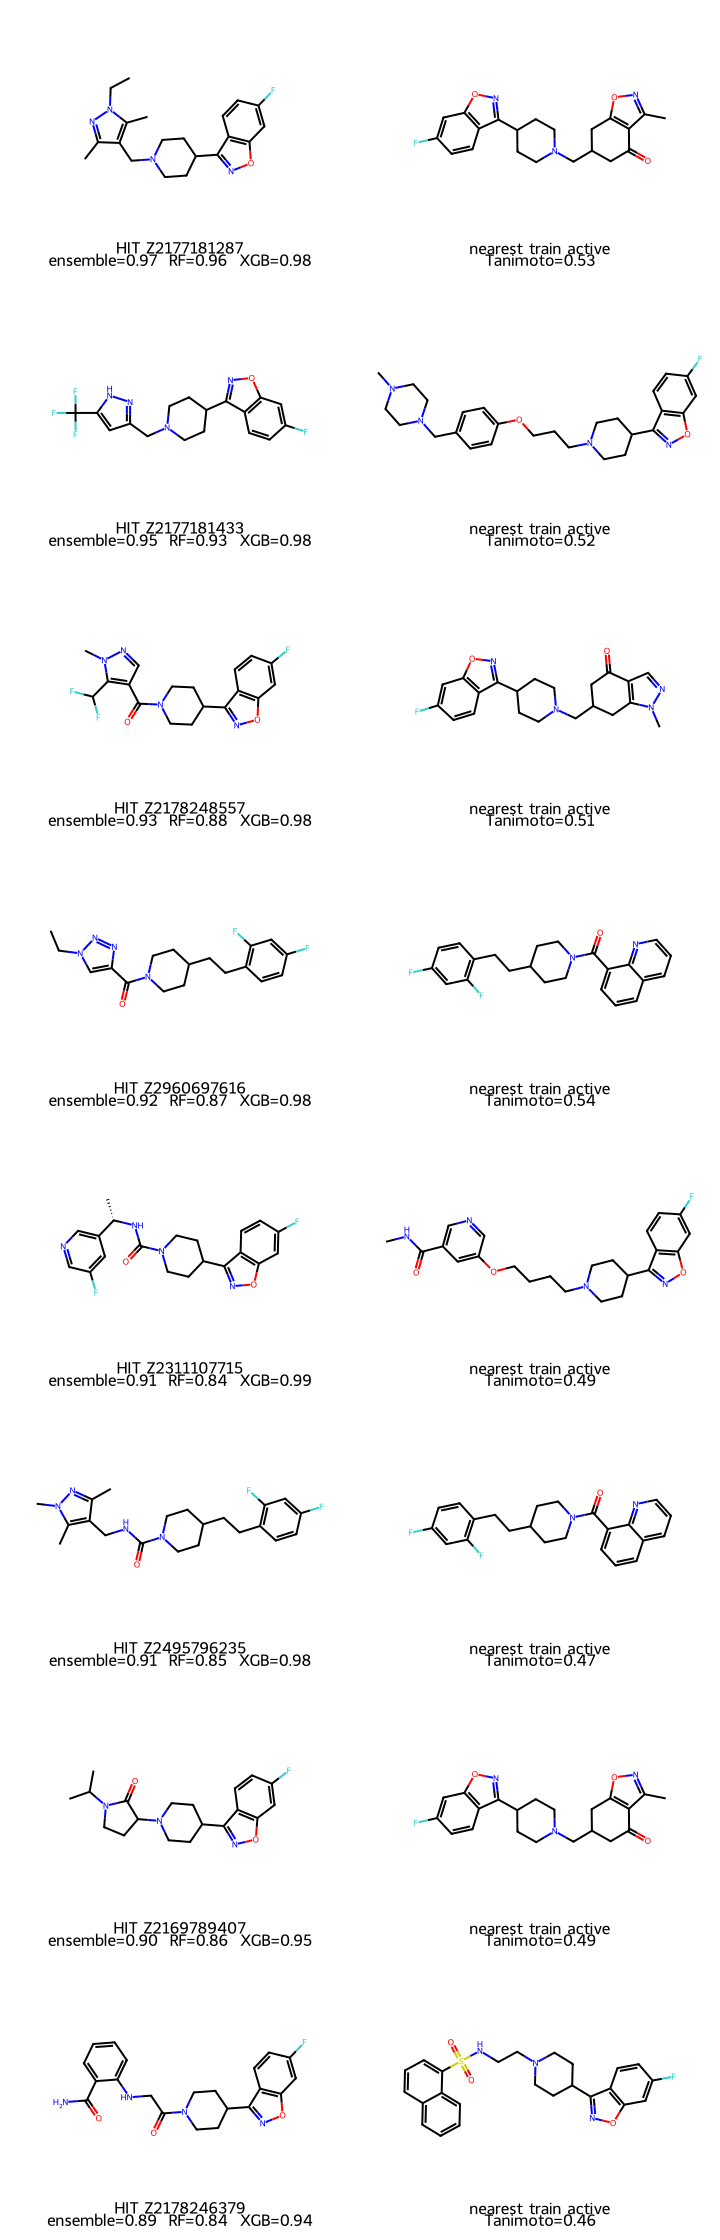

In [15]:
fig_mols, fig_legends = [], []
for _, row in final.iterrows():
    hit_mol = Chem.MolFromSmiles(row["smiles_std"])
    nn_mol  = Chem.MolFromSmiles(row["nn_train_smiles"])
    fig_mols.extend([hit_mol, nn_mol])
    fig_legends.append(f"HIT {row['ID']}\nensemble={row['ensemble']:.2f}  "
                       f"RF={row['rf_proba']:.2f}  XGB={row['xgb_proba']:.2f}")
    fig_legends.append(f"nearest train active\nTanimoto={row['nn_tanimoto']:.2f}")

img = Draw.MolsToGridImage(fig_mols, legends=fig_legends, molsPerRow=2,
                            subImgSize=(360, 280))
img

The final hits share a recurring structural pattern: a basic amine in a piperidine ring flanked by aromatic groups via short linkers, often featuring a carbonyl group adjacent to the amine. This corresponds to the canonical aminergic GPCR ligand pharmacophore.

In [16]:
final.to_csv(RESULTS_DIR / "final_hits.csv", index=False)
passed.to_csv(RESULTS_DIR / "all_passed.csv", index=False)
print(f"Saved {RESULTS_DIR / 'final_hits.csv'}")
print(f"Saved {RESULTS_DIR / 'all_passed.csv'}  ({len(passed):,} candidates)")

Saved G:\School\letni_2025\CDD\cdd2026\jirouset\data\processed\screen\final_hits.csv
Saved G:\School\letni_2025\CDD\cdd2026\jirouset\data\processed\screen\all_passed.csv  (736 candidates)


## Cross-check against ChEMBL
 * Query ChEMBL by InChIKey to confirm hits aren't already documented as 5-HT2A ligands

In [17]:
try:
    from chembl_webresource_client.new_client import new_client
    molecule = new_client.molecule
    activity = new_client.activity

    for _, row in final.iterrows():
        hits = molecule.filter(
            molecule_structures__standard_inchi_key=row["inchikey"]
        ).only(["molecule_chembl_id", "pref_name"])
        hits = list(hits)
        if not hits:
            print(f"{row['ID']:20s}  not in ChEMBL — novel")
            continue
        chembl_id = hits[0]["molecule_chembl_id"]
        # Activity records against HTR2A (target ChEMBL ID: CHEMBL224)
        acts = activity.filter(molecule_chembl_id=chembl_id, target_chembl_id="CHEMBL224")
        acts = list(acts)
        print(f"{row['ID']:20s}  ChEMBL {chembl_id} — "
              f"{len(acts)} HTR2A activity records")
except ImportError:
    print("chembl_webresource_client not installed; skip cross-check.")
except Exception as e:
    print(f"ChEMBL lookup failed: {e}")

Z2177181287           not in ChEMBL — novel
Z2177181433           not in ChEMBL — novel
Z2178248557           not in ChEMBL — novel
Z2960697616           not in ChEMBL — novel
Z2311107715           not in ChEMBL — novel
Z2495796235           not in ChEMBL — novel
Z2169789407           not in ChEMBL — novel
Z2178246379           not in ChEMBL — novel
